<a href="https://colab.research.google.com/github/Pam-Pam29/WEMA-Women-s-Emergency-Medical-AI/blob/main/WEMA_Data_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# WEMA : Data Exploration & Engineering

**Women's Emergency Medical AI · Capstone**

This notebook explores and characterises WEMA's two labelled data assets:

1. **Clinical knowledge base** — the WHO/ACOG guideline passages that ground every WEMA response.
2. **Evaluation scenarios** — the 68 labelled emergency cases used as evaluation ground truth.

---

## 1. Setup

In [1]:
!pip install -q langchain-community chromadb sentence-transformers openpyxl matplotlib pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Configuration

`COLLECTION_NAME` and `EMBEDDING_MODEL` must match `rag.py` exactly, or the notebook reads the wrong store.

In [3]:
import os
PROJECT         = "/content/drive/MyDrive/WEMA-Women-s-Emergency-Medical-AI"
CHROMA_DIR      = f"{PROJECT}/knowledge_base"
COLLECTION_NAME = "wema_maternal_health"
SCENARIOS_PATH  = f"{PROJECT}/WEMA_Labeled_Dataset.xlsx"
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# WEMA palette
GREEN, CORAL, INK, GREY = "#1D9E75", "#D85A30", "#0F2D2E", "#5B6E6E"
PURPLE, BLUE = "#7B6D8D", "#3A7CA5"

print("store folder exists:   ", os.path.isdir(CHROMA_DIR))
print("scenarios file exists: ", os.path.isfile(SCENARIOS_PATH))

store folder exists:    True
scenarios file exists:  True


In [ ]:
ssag

---
## Part 1 — The Clinical Knowledge Base

The knowledge base is the set of clinical guidelines WEMA retrieves from. Rather than answering from
memory, WEMA grounds every response in these passages. The cell below connects to the **live store**
and counts the current number of Passages so the figure reflects the store exactly as it is now.

### 1A. Live chunk count (read from the store, never hardcoded)

In [4]:
import chromadb, collections

client = chromadb.PersistentClient(path=CHROMA_DIR)
col = client.get_collection(COLLECTION_NAME)
meta = col.get(include=["metadatas"])["metadatas"]

total_chunks = col.count()
print(f"LIVE chunk count in store: {total_chunks}")

# chunks per source document
counts = collections.Counter(
    (m or {}).get("source_file", (m or {}).get("source","?"))
    for m in meta
)
# clean filenames to just the name
def short(s):
    return str(s).replace("\\","/").split("/")[-1]
doc_counts = collections.Counter()
for k,v in counts.items():
    doc_counts[short(k)] += v

kb = (pd.DataFrame(doc_counts.items(), columns=["document","chunks"])
        .sort_values("chunks", ascending=False).reset_index(drop=True))
print(f"{len(kb)} source documents · {kb['chunks'].sum()} chunks total")
kb

LIVE chunk count in store: 7906
19 source documents · 7906 chunks total


,document,chunks
0,9789241549356-eng.pdf,1591
1,WHO_Maternal_Guidelines_2025.pdf,1431
2,managing pregnany for midwife and docors.pdf,892
3,Clinical management of obstetric and neonatal ...,629
4,9789240115835-eng.pdf,446
5,WHO recommendations on antiplatelet agents for...,405
6,WHO recommendations Uterotonics for prevention...,327
7,lee-et-al-2025-part-5-neonatal-resuscitation-2...,285
8,WHO recommendations on the assessment of postp...,239
9,WHO recommendations on the management of sickl...,233


**Reading this:** the chunk count is read directly from ChromaDB at run time, so it always reflects
the current state of the store (after any cleaning). The longest WHO guidelines naturally contribute the
most chunks — chunk count tracks document length, not editorial weighting.

### 1B. Knowledge base composition — chunks per document

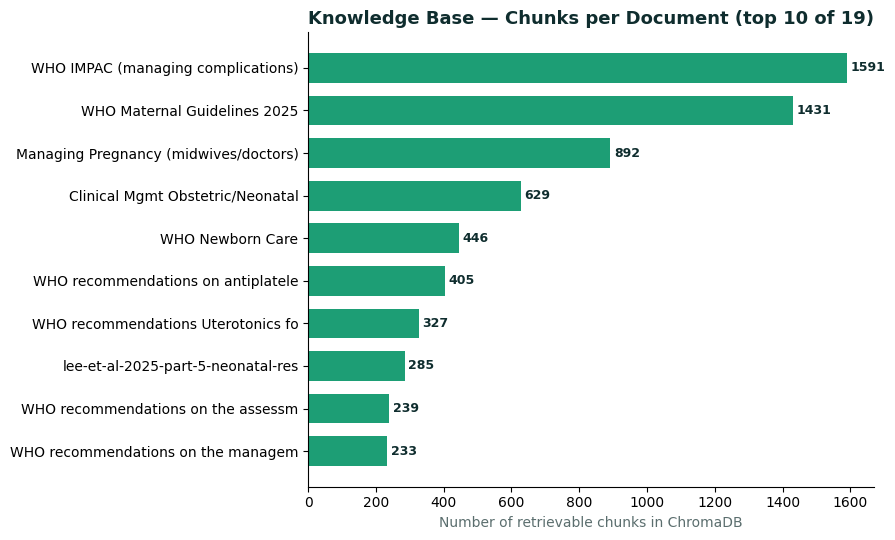

In [5]:
# readable short labels for the top documents
label_map = {
    "9789241549356-eng.pdf": "WHO IMPAC (managing complications)",
    "WHO_Maternal_Guidelines_2025.pdf": "WHO Maternal Guidelines 2025",
    "managing pregnany for midwife and docors.pdf": "Managing Pregnancy (midwives/doctors)",
    "Clinical management of obstetric and neonatal emergencies in Africa.pdf": "Clinical Mgmt Obstetric/Neonatal",
    "lee-et-al-2025-part-5-neonatal-resuscitation-2025.pdf": "Neonatal Resuscitation 2025",
    "9789240115835-eng.pdf": "WHO Newborn Care",
}
kb_plot = kb.copy()
kb_plot["label"] = kb_plot["document"].map(lambda d: label_map.get(d, d[:34]))
top = kb_plot.head(10).sort_values("chunks")

fig, ax = plt.subplots(figsize=(9,5.5))
ax.barh(top["label"], top["chunks"], color=GREEN, height=0.7)
for i,(v) in enumerate(top["chunks"]):
    ax.text(v+10, i, str(v), va="center", fontsize=9, color=INK, fontweight="bold")
ax.set_title(f"Knowledge Base — Chunks per Document (top 10 of {len(kb)})",
             fontweight="bold", color=INK, fontsize=13)
ax.set_xlabel("Number of retrievable chunks in ChromaDB", color=GREY)
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

---
## Part 2 — The Evaluation Scenarios

68 labelled test cases across 17 emergency types. Each scenario has a caller script, the expected
correct home action, a risk level, and an alerting decision — the ground truth WEMA is measured against.

### 2A. Load and summarise

In [6]:
scen = pd.read_excel(SCENARIOS_PATH)
print(f"{len(scen)} scenarios · {len(scen.columns)} columns")
print(f"emergency types: {scen['emergency_type'].nunique()}")
scen[["scenario_id","emergency_type","severity","expected_risk_level","expected_sms_triggered"]].head()

68 scenarios · 39 columns
emergency types: 17


,scenario_id,emergency_type,severity,expected_risk_level,expected_sms_triggered
0,S001,Postpartum Haemorrhage,Critical,High,Yes
1,S002,Postpartum Haemorrhage,Critical,High,Yes
2,S003,Postpartum Haemorrhage,Critical,High,Yes
3,S004,Postpartum Haemorrhage,Moderate,Medium,No
4,S005,Postpartum Haemorrhage,Critical,High,Yes


### 2B. Scenarios by emergency type

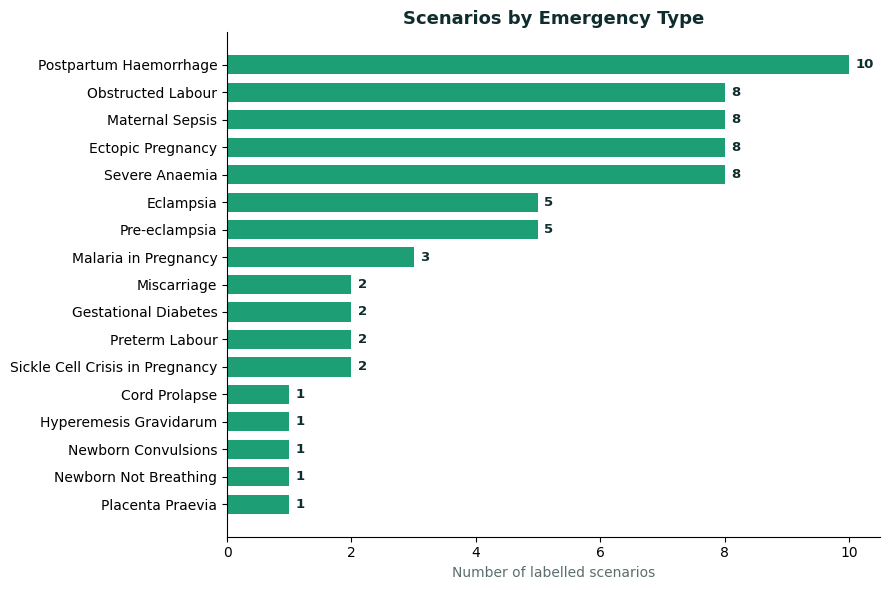

The leading direct causes of maternal death (PPH, sepsis, obstructed labour, eclampsia) are represented most heavily — by design.


In [7]:
vc = scen["emergency_type"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(9,6))
ax.barh(vc.index, vc.values, color=GREEN, height=0.7)
for i,v in enumerate(vc.values):
    ax.text(v+0.1, i, str(v), va="center", fontsize=9.5, color=INK, fontweight="bold")
ax.set_title("Scenarios by Emergency Type", fontweight="bold", color=INK, fontsize=13)
ax.set_xlabel("Number of labelled scenarios", color=GREY)
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

print("The leading direct causes of maternal death (PPH, sepsis, obstructed labour, "
      "eclampsia) are represented most heavily — by design.")

### 2C. Distribution by risk level and clinical severity

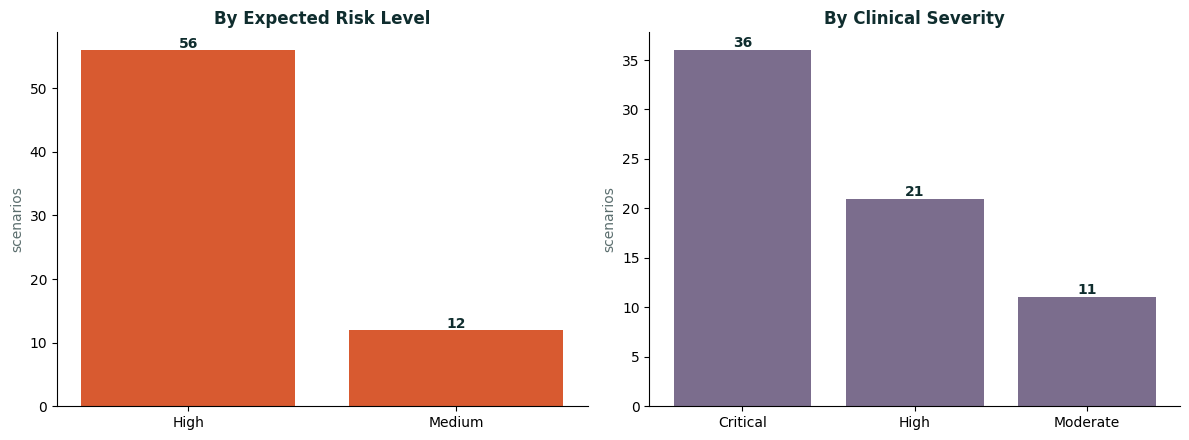

The set skews high-risk by design — these are emergencies. Results are therefore read per emergency type, not as one headline number.


In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12,4.5))

for ax, colname, color, title in [
    (axs[0], "expected_risk_level", CORAL, "By Expected Risk Level"),
    (axs[1], "severity", PURPLE, "By Clinical Severity"),
]:
    if colname in scen.columns:
        vc2 = scen[colname].value_counts()
        ax.bar(vc2.index.astype(str), vc2.values, color=color)
        for i,v in enumerate(vc2.values):
            ax.text(i, v+0.3, str(v), ha="center", fontsize=10, color=INK, fontweight="bold")
        ax.set_title(title, fontweight="bold", color=INK)
        ax.set_ylabel("scenarios", color=GREY)
        for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

print("The set skews high-risk by design — these are emergencies. Results are therefore read "
      "per emergency type, not as one headline number.")

### 2D. Alerting decisions (SMS trigger)

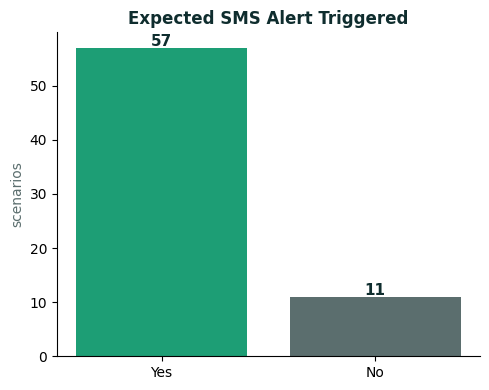

In [9]:
if "expected_sms_triggered" in scen.columns:
    sms = scen["expected_sms_triggered"].value_counts()
    fig, ax = plt.subplots(figsize=(5,4))
    ax.bar(sms.index.astype(str), sms.values, color=[GREEN if str(x).lower() in ("yes","true","1") else GREY for x in sms.index])
    for i,v in enumerate(sms.values):
        ax.text(i, v+0.3, str(v), ha="center", fontsize=11, color=INK, fontweight="bold")
    ax.set_title("Expected SMS Alert Triggered", fontweight="bold", color=INK)
    ax.set_ylabel("scenarios", color=GREY)
    for s in ["top","right"]: ax.spines[s].set_visible(False)
    plt.tight_layout(); plt.show()

### 2E. Data dictionary

In [10]:
# show the columns and their types — useful documentation of the dataset structure
dd = pd.DataFrame({
    "column": scen.columns,
    "non_null": [scen[c].notna().sum() for c in scen.columns],
    "example": [str(scen[c].dropna().iloc[0])[:40] if scen[c].notna().any() else "" for c in scen.columns],
})
print(f"{len(scen.columns)} columns total")
dd

39 columns total


,column,non_null,example
0,scenario_id,68,S001
1,emergency_type,68,Postpartum Haemorrhage
2,emergency_category,68,Haemorrhage
3,trimester_stage,68,Postpartum
4,severity,68,Critical
5,language,68,English
6,caller_location,68,"Alimosho, Lagos"
7,caller_age,68,28
8,gestational_age_weeks,68,40
9,caller_script,68,I just gave birth one hour ago and I can


---
## Summary

- **Knowledge base:** counted live from ChromaDB — see the figure printed above (count reflects the
  store after cleaning; non-content chunks such as referral forms, citations and headers were removed
  during preprocessing).
- **Evaluation scenarios:** 68 labelled cases across 17 emergency types, skewed toward high-acuity
  emergencies by design, each with an expected home action and alerting decision.
- Every figure in this notebook is generated from the live store and the actual data file — no counts
  are hardcoded, so the notebook never goes stale.